# Exploratory analysis — Online Retail II

Questions before modelling: how much data survives cleaning, how sales move over time, where customers are, and how often they come back. Requires the database loaded with `src/load_to_postgres.py`.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd

from db import get_engine

engine = get_engine()
COLOR = "#2a6fdb"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

## 1. How much data survives cleaning?
Rows without a customer ID cannot be linked to a person, so they are useless for churn. Cancellations, postage and fees are removed too (see `sql/02_clean_view.sql`).

In [2]:
pd.read_sql("""
SELECT
    (SELECT COUNT(*) FROM raw_transactions)   AS raw_rows,
    (SELECT COUNT(*) FROM clean_transactions) AS clean_rows,
    (SELECT COUNT(*) FROM raw_transactions WHERE customer_id IS NULL) AS rows_without_customer,
    (SELECT COUNT(DISTINCT customer_id) FROM clean_transactions) AS customers
""", engine)

,raw_rows,clean_rows,rows_without_customer,customers
0,1033036,776583,235151,5852


## 2. Revenue per month
Strong seasonality: sales climb from September to November (Christmas wholesale orders). December 2011 only has 9 days of data, so it looks like a drop but is not.

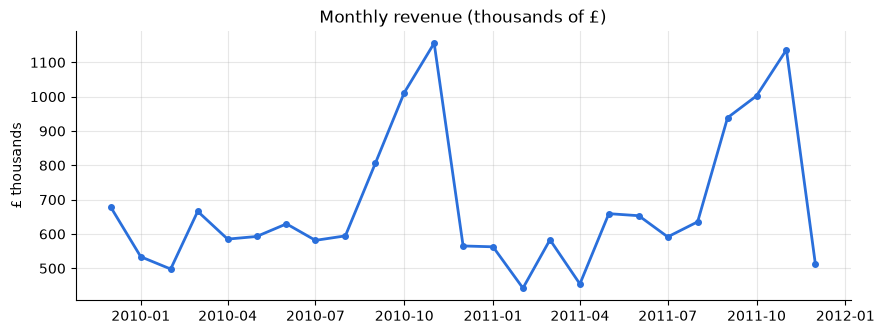

In [3]:
monthly = pd.read_sql("""
SELECT DATE_TRUNC('month', invoice_date)::date AS month,
       SUM(line_total) AS revenue,
       COUNT(DISTINCT customer_id) AS active_customers
FROM clean_transactions
GROUP BY 1 ORDER BY 1
""", engine, parse_dates=["month"])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(monthly["month"], monthly["revenue"] / 1000, color=COLOR, linewidth=2, marker="o", markersize=4)
ax.set(title="Monthly revenue (thousands of £)", ylabel="£ thousands")
plt.savefig("../reports/figures/eda_monthly_revenue.png", dpi=120, bbox_inches="tight")
plt.show()

Revenue and active customers have different scales, so they get separate charts instead of one chart with two y-axes.

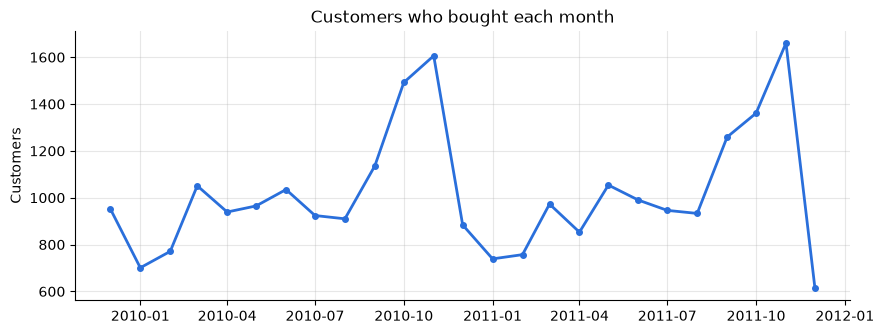

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(monthly["month"], monthly["active_customers"], color=COLOR, linewidth=2, marker="o", markersize=4)
ax.set(title="Customers who bought each month", ylabel="Customers")
plt.show()

## 3. Where are the customers?
The UK concentrates most customers and revenue. That is why the model has an `is_uk` feature.

In [5]:
countries = pd.read_sql("""
SELECT country, COUNT(DISTINCT customer_id) AS customers, SUM(line_total) AS revenue
FROM clean_transactions
GROUP BY country ORDER BY revenue DESC LIMIT 10
""", engine)
countries["revenue_share"] = countries["revenue"] / pd.read_sql(
    "SELECT SUM(line_total) AS total FROM clean_transactions", engine)["total"][0]
countries

,country,customers,revenue,revenue_share
0,United Kingdom,5334,1.428951e+07,0.837146
1,EIRE,3,5.866261e+05,0.034367
2,Netherlands,22,5.497734e+05,0.032208
3,Germany,107,3.832890e+05,0.022455
4,France,93,3.094032e+05,0.018126
5,Australia,15,1.678000e+05,0.009831
6,Spain,38,9.776675e+04,0.005728
7,Switzerland,22,9.340094e+04,0.005472
8,Sweden,19,8.604514e+04,0.005041
9,Denmark,12,6.742269e+04,0.003950


## 4. How many times does a customer buy?
This is the key chart for churn: more than a quarter of customers (28%) placed a single order in two years.

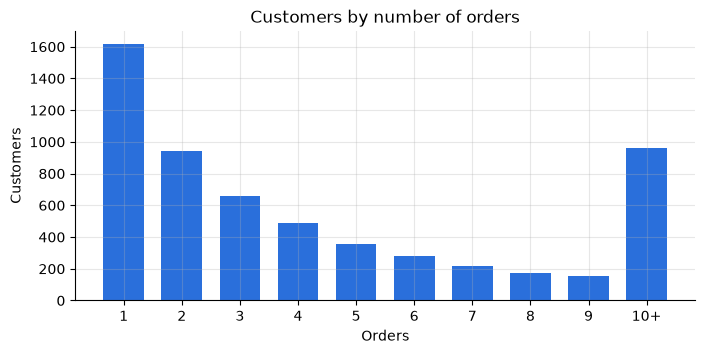

Customers with a single order: 28%


In [6]:
orders = pd.read_sql("""
SELECT customer_id, COUNT(DISTINCT invoice) AS orders
FROM clean_transactions GROUP BY customer_id
""", engine)

counts = orders["orders"].clip(upper=10).value_counts().sort_index()
labels = [str(n) if n < 10 else "10+" for n in counts.index]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(labels, counts.values, color=COLOR, width=0.7)
ax.set(title="Customers by number of orders", xlabel="Orders", ylabel="Customers")
plt.savefig("../reports/figures/eda_orders_per_customer.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Customers with a single order: {(orders['orders'] == 1).mean():.0%}")

## 5. Segments: few customers, most of the money
Result of `src/segment_customers.py`.

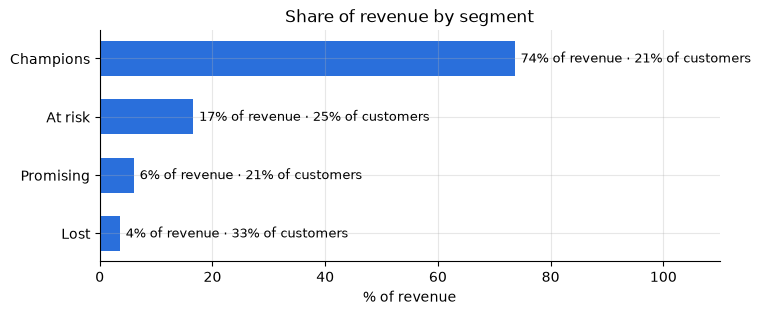

In [7]:
segments = pd.read_sql("""
SELECT segment, COUNT(*) AS customers, SUM(monetary) AS revenue
FROM customer_segments GROUP BY segment
""", engine)
segments["customer_share"] = segments["customers"] / segments["customers"].sum()
segments["revenue_share"] = segments["revenue"] / segments["revenue"].sum()
segments = segments.sort_values("revenue_share")

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(segments["segment"], segments["revenue_share"] * 100, color=COLOR, height=0.6)
for y, (share, cust) in enumerate(zip(segments["revenue_share"], segments["customer_share"])):
    ax.text(share * 100 + 1, y, f"{share:.0%} of revenue · {cust:.0%} of customers", va="center", fontsize=9)
ax.set(title="Share of revenue by segment", xlabel="% of revenue", xlim=(0, 110))
plt.savefig("../reports/figures/eda_segments_revenue.png", dpi=120, bbox_inches="tight")
plt.show()

## Takeaways
- Almost a quarter (23%) of the raw rows have no customer and are dropped.
- Sales are seasonal (peak in November), so the churn window (Sep–Dec 2011) falls in the busiest season: churn measured there is probably lower than in a quiet season.
- 28% of customers bought only once: recency and frequency should be the strongest churn signals.
- Champions are a minority of customers but bring most of the revenue: they are the ones worth protecting.